## Basis Size and Success Criteria

If we want to adjust how many first chapters are used or how many chapters a series must publish in order to be considered a success we can do so below.

In [66]:
# How many chapters we should consider when making the prediction.
basis_size=12

# The minimum number of chapters for a series to be considered a success.
success_criteria=50

# Loading Libraries

This project requires numerous Python libraries which are loaded below.

In [67]:
# We will obtain data from the SQlite database.
import sqlite3

# We will use the following for handling data and creating figures and charts.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# We use the following for preprocessing data and evaluating models.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.base import clone

# We employ a suite of models to determine which may work best.
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# We use pickle to save the best model.
import pickle

# We set the seed for replicability.
np.random.seed(1)


# Obtaining Data

We will use data taken from our SQLite database. In this section we perform the necessary work to obtain a Pandas dataframe where each row corresponds to a series in the magazine and each column represents a feature which might indicate early success or failure.  First we connect to the database and note the current range of dates.

In [68]:
connection=sqlite3.connect('shonen_jump.sqlite3')
cursor=connection.cursor()
cursor.execute("""SELECT MIN(release_date), MAX(release_date) FROM chapters;""")
date_range=cursor.fetchone()

In [69]:
print(f"When this notebook was last run the demo database contained chapters between {date_range[0]} and {date_range[1]}.")

When this notebook was last run the demo database contained chapters between 2022-01-16 and 2025-11-09.


Next we query the database to gather information on series whose early performance and ultimate success/failure is known so that we can obtain a dataset for training our model.  Read the comments inside the query for a better understanding of what columns are being assembled.  Each row of the resulting query corresponds to one series.

In [70]:
df=pd.read_sql_query("""
-- We want the name and genre of each series.                     
SELECT title,genre,  
-- Next we want an indicator column where 1 indicates that the series has one creator (who both writes and draws) and 
-- 0 if the series has a different artist and writer.  We call this column one_creator.
CASE
WHEN writer=artist THEN 1
ELSE 0 END one_creator,
-- We create a second indicator which produces 1 if the series is successful (runs for at least success_criteria chapters)
-- and 0 otherwise.  We call this column success.              
CASE
WHEN total_chapters>=:success_criteria THEN 1
ELSE 0 END success,
-- We also want to track what the average placement of the series was, how many color pages it received, and how many times it landed
-- on the cover page over its first basis_size number of chapters. These columns will be obtained below.
average_placement,
color_pages,
cover_pages,
-- Finally we want the debut date and the size of the batch the series started in.
debuts.release_date,
batches.added AS batch_size

-- We now begin obtaining the above columns and selecting series where we know both their early performance and overall success/failure. 
FROM series
-- By inner joining with debuts we restrict ourselves to series where the database includes chapters starting from 1.
INNER JOIN debuts ON title=debuts.series
-- We join with a selection which averages the placement of each series over its first basis_size chapters
LEFT JOIN (SELECT AVG(placement) AS average_placement, series FROM chapters
WHERE chapter<=:basis_size GROUP BY series) AS avplace
ON title=avplace.series
-- We join again with a selection which counts the number of color pages over the series' first basis_size chapters.
LEFT JOIN (SELECT series,COUNT(series) AS color_pages FROM chapters
WHERE type='Color' AND chapter<=:basis_size
GROUP BY series) AS colorp
ON title=colorp.series
-- We join again with a selection which counts the number of cover pages over the series' first basis_size chapters.
LEFT JOIN (SELECT series,COUNT(series) AS cover_pages FROM chapters
WHERE type='Cover' AND chapter<=:basis_size
GROUP BY series) AS coverp
ON title=coverp.series
-- We also join with batches by associating to each series' debut the batch it lands within.
LEFT JOIN batches ON debuts.release_date BETWEEN batches.start_date AND batches.end_date
-- Finally we only select series who have achieved success by our criteria or have completed.
WHERE total_chapters>=9
ORDER BY title;
                """, con=connection, params={'basis_size':basis_size,'success_criteria':success_criteria})

Summarizing the comments in the above SQL query we have that the resulting dataframe only includes series which satisfy the following conditions:

1. The database has information on the series starting from chapter 1. We aren't considering series which started before the earliest date in the database even if we have information on later chapters.
2. The success or failure of the series is currently known, i.e. either:
    * The series has run for at least `success_criteria` chapters (it succeeded).
    * The series is completed (and can be said to have failed if it didn't reach `success_criteria` chapters).

Where 1 ensures we have information on starting success and 2 ensures we have information on overall success or failure.

In [71]:
# We close the connection now that we have obtained all the information from the database we need.
connection.close()

# Data Overview and Feature Engineering

The dataset requires little cleaning because the SQL query eliminated most unnecessary information or series where we lacked sufficient information to use for training purposes. 

In [72]:
df

,title,genre,one_creator,success,average_placement,color_pages,cover_pages,release_date,batch_size
0,Akane-banashi,Other,0,1,7.750000,2,1,2022-02-13,2
1,Aliens Area,Battle,1,0,11.416667,2,1,2022-06-05,3
2,Astro Royale,Battle,1,1,8.500000,2,1,2024-04-14,3
3,Cipher Academy,Other,0,1,10.250000,1,1,2022-11-20,4
4,Dear Anemone,Battle,1,0,12.250000,1,1,2024-02-18,2
5,Do Retry,Sports,1,0,13.000000,1,1,2023-05-07,4
6,Earthchild,Other,1,0,9.666667,2,1,2022-02-20,2
7,Ekiden Bros,Sports,1,0,12.666667,1,1,2025-06-29,4
8,Embers,Sports,0,0,12.500000,1,1,2025-02-02,2
9,Fabricant 100,Battle,1,0,11.250000,1,1,2022-12-04,4


In [73]:
with open('Demo_Classifier.pkl', 'rb') as f:
    loader = pickle.load(f)

In [74]:
trained_on=loader[1]['Trained On']
trained_on

['Shadow Eliminators',
 'Martial Master Asumi',
 'Psych House',
 "Ichigoki's Under Control!!",
 'Two on Ice',
 'Do Retry',
 'Shinobi Undercover',
 'Ultimate Exorcist Kiyoshi',
 'Aliens Area',
 'Kagurabachi',
 'Astro Royale',
 'Kaedegami',
 'Ice-Head Gill',
 'Ekiden Bros',
 'Hakutaku',
 'Kyokuto Necromance',
 'Tokyo Demon Bride Story',
 'Earthchild',
 'Nice Prison',
 "The Ichinose Family's Deadly Sins",
 'Syd Craft: Love Is a Mystery',
 'Fabricant 100',
 'Ping-Pong Peril',
 'Green Green Greens',
 'Ginka & Glüna',
 'Kill Blue',
 'MamaYuyu',
 'Akane-banashi',
 'Embers',
 'Cipher Academy',
 "Nue's Exorcist"]

In [75]:
loaded_model=loader[0]

A quick inspection reveals that all series had exactly one cover page.  We can remove this column.

In [76]:
df.drop(columns=['cover_pages'],inplace=True)

We will extract the year and month from the release_date column.

In [77]:
df['release_date']=pd.to_datetime(df['release_date'])
df['release_year']=df['release_date'].dt.year
df['release_month']=df['release_date'].dt.month

In [78]:
df

,title,genre,one_creator,success,average_placement,color_pages,release_date,batch_size,release_year,release_month
0,Akane-banashi,Other,0,1,7.750000,2,2022-02-13,2,2022,2
1,Aliens Area,Battle,1,0,11.416667,2,2022-06-05,3,2022,6
2,Astro Royale,Battle,1,1,8.500000,2,2024-04-14,3,2024,4
3,Cipher Academy,Other,0,1,10.250000,1,2022-11-20,4,2022,11
4,Dear Anemone,Battle,1,0,12.250000,1,2024-02-18,2,2024,2
5,Do Retry,Sports,1,0,13.000000,1,2023-05-07,4,2023,5
6,Earthchild,Other,1,0,9.666667,2,2022-02-20,2,2022,2
7,Ekiden Bros,Sports,1,0,12.666667,1,2025-06-29,4,2025,6
8,Embers,Sports,0,0,12.500000,1,2025-02-02,2,2025,2
9,Fabricant 100,Battle,1,0,11.250000,1,2022-12-04,4,2022,12


In [79]:
cut_down=df[~df['title'].isin(trained_on)].drop(columns=['success'])
cut_down

,title,genre,one_creator,average_placement,color_pages,release_date,batch_size,release_year,release_month
4,Dear Anemone,Battle,1,12.250000,1,2024-02-18,2,2024,2
13,Harukaze Mound,Sports,0,9.833333,2,2025-06-15,4,2025,6
14,Hima-Ten!,Romance,1,7.833333,2,2024-07-07,3,2024,7
16,Ichi the Witch,Battle,0,5.916667,3,2024-09-08,3,2024,9
18,Jujutsu Kaisen Modulo,Battle,0,6.200000,3,2025-09-07,2,2025,9
27,Otr of the Flame,Battle,1,11.166667,1,2025-05-11,2,2025,5
30,RuriDragon,Other,1,13.000000,2,2022-06-12,3,2022,6
33,Someone Hertz,Romance,1,7.000000,2,2025-09-14,2,2025,9
34,Star of Beethoven,Other,1,12.250000,1,2025-02-09,2,2025,2
35,Super Psychic Policeman Chojo,Comedy,1,6.583333,3,2024-02-11,2,2024,2


In [80]:
cut_down

,title,genre,one_creator,average_placement,color_pages,release_date,batch_size,release_year,release_month
4,Dear Anemone,Battle,1,12.250000,1,2024-02-18,2,2024,2
13,Harukaze Mound,Sports,0,9.833333,2,2025-06-15,4,2025,6
14,Hima-Ten!,Romance,1,7.833333,2,2024-07-07,3,2024,7
16,Ichi the Witch,Battle,0,5.916667,3,2024-09-08,3,2024,9
18,Jujutsu Kaisen Modulo,Battle,0,6.200000,3,2025-09-07,2,2025,9
27,Otr of the Flame,Battle,1,11.166667,1,2025-05-11,2,2025,5
30,RuriDragon,Other,1,13.000000,2,2022-06-12,3,2022,6
33,Someone Hertz,Romance,1,7.000000,2,2025-09-14,2,2025,9
34,Star of Beethoven,Other,1,12.250000,1,2025-02-09,2,2025,2
35,Super Psychic Policeman Chojo,Comedy,1,6.583333,3,2024-02-11,2,2024,2


In [65]:
loaded_model.predict(cut_down)

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0], dtype=int64)

In [81]:
loaded_model.score(cut_down,[0,0,1,1,1,0,1,1,0,1,0,0,0])

0.7692307692307693

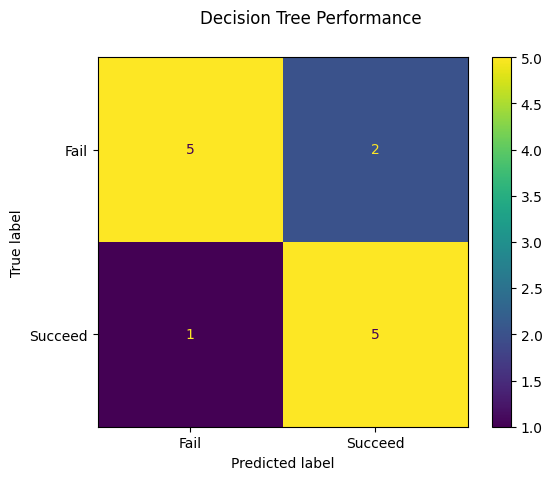

In [82]:
# Defining the matrix.
c_matrix = metrics.confusion_matrix([0,0,1,1,1,0,1,1,0,1,0,0,0], loaded_model.predict(cut_down), labels=[0,1])

# Setting the display options.
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = c_matrix, display_labels = ['Fail', 'Succeed'])
cm_display.plot()
# Adding a title.
plt.gcf().suptitle('Decision Tree Performance')
# Removing grid lines for clarity.
plt.grid(False)
plt.show()